# Robust PCA
## Problem

We want to solve

$$\min\limits_{X\in\mathbb{R}^{n\times m}} f(X) + \iota_{\mathcal{C}}(X) + \iota_{[0,1]^{n\times m}}(X)$$
where 
$$\mathcal{C} = \{U\in\mathbb{R}^{n\times m}\colon \|U\|_*\leq \rho\}$$

is the set of $n\times m$ matrices with nuclear norm less than $\rho$.

We will take 

$$f(X) := \sum\limits_{i,j\in [[p,q]]}f_0(\mathcal{A}(X)_{i,j} - b_{i,j})$$

for some linear operator $\mathcal{A}\colon\mathbb{R}^{n\times m}\to \mathbb{R}^{p\times q}$ which gives us the observed pixels in the form of a subimage of size $p\times q$ and for the function $f_0\colon\mathbb{R}\to\mathbb{R}$ given by

$$f_0(x) = \frac{x^2}{2\delta^2 + x^2}$$

for some small $\delta>0$.

The derivative of $f_0$ is given by

$$f_0'(x) = \frac{4\delta^2 x}{(2\delta^2 + x^2)^2}$$

The nonsmooth function $g$ will be taken to be

$$g(X) = \iota_{[0,1]^{n\times m}}(X)$$

whose projection is just clamping componentwise to $[0,1]$.

In [1]:
import cupy as cp
import numpy as np
import fw_functions_cupy as fw
from PIL import Image
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio

In [2]:
# Load the grayscale image
image = cp.array(Image.open('house.jpg').convert('L')) / 255
# Get the dimensions of the image
height, width = image.shape

# Create a mask for inpainting
observed_indices_mask = cp.ones((height, width), dtype=bool)

# Generate 25 squares of size 5x5
num_squares = 100
square_size = 20

num_observed_pixels = num_squares * (square_size**2)

for _ in range(num_squares):
    # Randomly select the top-left corner of the square
    top_left_row = cp.random.randint(0, height - square_size + 1)
    top_left_col = cp.random.randint(0, width - square_size + 1)

    # Create a slice for the square region
    square_slice = cp.s_[top_left_row:top_left_row+square_size, top_left_col:top_left_col+square_size]

    # Set the pixels in the square region to False (masked)
    observed_indices_mask[square_slice] = False

observations = image[observed_indices_mask]

# Create a copy of the image for adding noise
noisy_image = cp.copy(image)

# Apply salt and pepper noise with density 1/10
noise_density = 0.05

# Compute the total number of pixels in the observed squares
num_observed_pixels = cp.sum(observed_indices_mask)

# Compute the number of salt and pepper pixels based on the noise density
num_salt = cp.ceil(noise_density * num_observed_pixels)
num_pepper = num_salt

# Find the indices of the observed pixels in the squares
observed_indices = cp.nonzero(observed_indices_mask)

# Randomly select pixels for salt noise within the observed squares
salt_indices = cp.random.choice(cp.arange(num_observed_pixels), int(num_salt), replace=False)
salt_rows, salt_cols = observed_indices[0][salt_indices], observed_indices[1][salt_indices]
noisy_image[salt_rows, salt_cols] = 1.0

# Randomly select pixels for pepper noise within the observed squares
pepper_indices = cp.random.choice(cp.arange(num_observed_pixels), int(num_pepper), replace=False)
pepper_rows, pepper_cols = observed_indices[0][pepper_indices], observed_indices[1][pepper_indices]
noisy_image[pepper_rows, pepper_cols] = 0.0

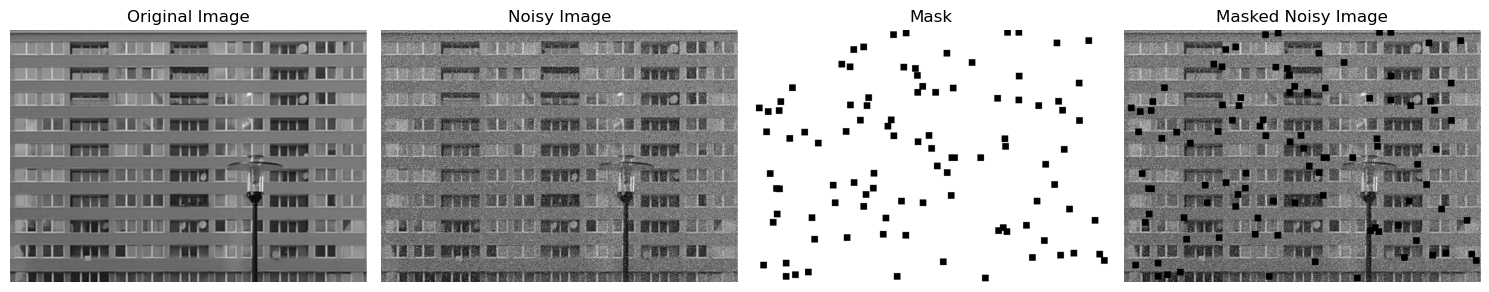

In [3]:
# Convert cupy arrays to numpy arrays for plotting
image_np = cp.asnumpy(image)
noisy_image_np = cp.asnumpy(noisy_image)
observed_indices_mask_np = cp.asnumpy(observed_indices_mask)

# Display the original image, noisy image, mask, and masked noisy image
fig, axs = plt.subplots(1, 4, figsize=(15, 5))
axs[0].imshow(image_np, cmap='gray')
axs[0].set_title('Original Image')
axs[0].axis('off')
axs[1].imshow(noisy_image_np, cmap='gray')
axs[1].set_title('Noisy Image')
axs[1].axis('off')
axs[2].imshow(observed_indices_mask_np, cmap='gray')
axs[2].set_title('Mask')
axs[2].axis('off')
axs[3].imshow(noisy_image_np * observed_indices_mask_np, cmap='gray')  # Multiply noisy_image with mask
axs[3].set_title('Masked Noisy Image')
axs[3].axis('off')
plt.tight_layout()
plt.show()
plt.close()  # Close the figure after displaying it

In [4]:
delta_values = [0.1, 1.0, 10.0, 50.0, 100.0, 150.0]
radius_coefficients = [0.5, .75, 1.0, 1.25, 1.5, 2.0]
# delta_values = [0.1]
# radius_coefficients = [0.5]

In [5]:
class RobustPCAObjective(fw.ObjectiveFunction):
  def __init__(self, delta, observed_indices_mask, observations):
      self.delta = delta
      self.observed_indices_mask = observed_indices_mask
      self.observations = observations

  def evaluate(self, X):
      X_observed = X[self.observed_indices_mask]
      diff = X_observed - self.observations
      return (diff**2/(2*(self.delta**2) + diff**2)).sum()

  def gradient(self, X):
      X_observed = X[self.observed_indices_mask]
      diff = X_observed - self.observations
      grad_observed = 4 * diff * (self.delta ** 2) / ((2 * (self.delta ** 2) + (diff ** 2)) ** 2)
      grad = cp.zeros_like(X)
      grad[self.observed_indices_mask] = grad_observed
      return grad

  def linear_operator(self, X):
      return X

  def linear_operator_adjoint(self, X):
      return X

  def minimal_norm_selection(self, X):
      pass

observations = noisy_image[observed_indices_mask]
X0 = cp.zeros_like(image)

# Initialize an array to store PSNR values
psnr_values = np.zeros((len(delta_values), len(radius_coefficients)))

for i, delta in enumerate(delta_values):
    for j, radius_coefficient in enumerate(radius_coefficients):
        # Create the LMO function
        radius = radius_coefficient * cp.linalg.norm(image, ord='nuc')
        constraint_set = 'nuclear_norm_ball'
        lmo_fn = fw.create_lmo(radius, constraint_set)

        # Create the prox function
        def prox_fn(X, beta):
            return fw.proj_cube(X)

        # Initialize the objective
        objective_fn = RobustPCAObjective(delta, observed_indices_mask, observations)
        objective_type = 'indicator'

        # Create an instance of the FrankWolfe class
        RobustPCA = fw.FrankWolfe(objective_fn, lmo_fn, prox_fn, objective_type)

        # Run the algorithm
        sol = RobustPCA.run(X0, beta0=1e15, n_steps=int(1e5))

        # Convert the solution to numpy array
        sol_np = cp.asnumpy(sol)

        # Calculate PSNR between the recovered image and ground truth
        psnr = peak_signal_noise_ratio(image_np, sol_np)

        # Store the PSNR value in the array
        psnr_values[i, j] = psnr

        # Save the recovered image as an image file
        image_filename = f"solution_delta_{delta}_radius_{radius_coefficient}.png"
        Image.fromarray((sol_np * 255).astype(np.uint8)).save(image_filename)
        npy_filename = f"solution_delta_{delta}_radius_{radius_coefficient}.npy"
        cp.save(npy_filename, sol)

# Print the PSNR values
print("PSNR values:")
print(psnr_values)

Frank-Wolfe Progress: 100%|██████████| 100000/100000 [45:11<00:00, 36.89it/s]


PSNR values:
[[15.79528997 22.83468625 24.72927759 27.670531   27.53910891 27.20385408]
 [23.30546729 27.68886031 26.67510331 25.28490365 23.92808545 21.59115177]
 [23.19976665 26.47160068 25.78198228 24.71258466 23.55762638 21.43740911]
 [23.19857016 26.46784114 25.76540837 24.67949255 23.54148541 21.45049998]
 [23.20083839 26.44394836 25.79009369 24.7170926  23.55343674 21.44525085]
 [23.19609351 26.48174985 25.7812314  24.70344604 23.5373594  21.43509063]]
